# Mode Seeking for Density-Based Clustering

## I. Introduction

### ToMATo and Mode-Seeking

ToMATo is an example of a topological, mode-seeking clustering algorithm. This simply means that ToMATo takes the following as a definition:

<div style="padding-left: 40px;">
A <b>cluster</b> is the maximal connected component containing a mode of the underlying probability distribution over the manifold from which the data are drawn.
</div>

<br>

This is a bit dense, so let's break this down a bit:
- We assume first that our data lies on some manifold.
- We also assume that our data are sampled from this manifold according to some probability distribution.
- A **mode** of this probability distribution is a point in the data at which the probability density function is locally maximal.
- A **connected component** is simply a set of data points that are contiguous.
- A **maximal** connected component of a mode is the set of all points that, if one follows the path of steepest ascent of the probability density function, eventually reach that mode.

The task of a clustering algorithm like ToMATo is then to understand what the data manifold looks like, how the sampled data is distributed on it, and to infer which modes correspond to the most stable clusters.

### Why define clusters like this?

Even broken down, this is still a dense defintion, and it's perhaps not clear yet why we might want to use it. In this notebook, we'll try to develop an intuitive understanding which clarifies why we might want to define clusters in this way. The easiest way to develop this intuition is to forget about the "manifold" part of the definition for the time being. Instead, we'll take a look at a simple dataset in which the data is distributed on a line in one dimension. Here, we will have a much easier time visualizing probability density estimates, modes, and clusters.

## II. Clustering in One Dimension

Let's get started with a look at clustering some one-dimensional data using a KDE to estimate density.

The large block of code below sets up some functions for visualizing this. Feel free to scroll past this.

### Plotting & Clustering Functions

In [1]:
from scipy import stats, signal
import numpy as np
import matplotlib.pyplot as plt


def cluster_by_kde_modes(data, kde_x, kde_y):
    data = np.asarray(data)

    valleys, _ = signal.find_peaks(-kde_y)
    valleys = [0, *valleys, kde_x.shape[0] - 1]
    boundaries = kde_x[valleys]

    boundaries = np.sort(boundaries)

    split_points = boundaries
    clusters = [
        data[(data >= split_points[i]) & (data < split_points[i + 1])]
        for i in range(len(split_points) - 1)
    ]
    clusters = [c for c in clusters if len(c) > 0]

    return clusters, valleys


def _plot_kde_clusters(clusters, boundaries, kde_x, kde_y, data_ax, kde_ax):

    px = kde_x[boundaries]
    py = kde_y[boundaries]
    kde_ax.scatter(px, py, facecolors="none", edgecolors="red")

    for i in range(len(boundaries) - 1):
        kde_xc = kde_x[boundaries[i]:boundaries[i+1]]
        kde_yc = kde_y[boundaries[i]:boundaries[i+1]]
        kde_ax.fill_between(kde_xc, kde_yc, alpha=0.1)

    for c in clusters:
        data_ax.scatter(c, np.zeros_like(c), alpha=0.25)
    
    return

def _plot_kde_peaks(kde_x, kde_y, ax):
    peaks, _ = signal.find_peaks(kde_y)
    px = kde_x[peaks]
    py = kde_y[peaks]
    ax.scatter(px, py, color="red")    
    return


def plot_kde(x, bw=None, show_peaks=False, show_clusters=False, return_clusters=False):
    
    kde = stats.gaussian_kde(x, bw_method=bw)

    x_range = x.max() - x.min()
    x_min = x.min() - 0.1 * x_range
    x_max = x.max() + 0.1 * x_range
    kde_x = np.linspace(x_min, x_max, x.shape[0])
    kde_y = kde(kde_x)
    
    fig, axs = plt.subplots(2, 1, sharex=True, height_ratios=[0.8, 0.2])
    axs[0].plot(kde_x, kde_y)
    if not show_clusters:
        axs[0].fill_between(kde_x, kde_y, alpha=0.1)
    axs[0].set_axis_off()
    if not show_clusters:
        axs[1].scatter(x, np.zeros_like(x), alpha=0.25)
    axs[1].set_axis_off()

    if show_peaks:
        _plot_kde_peaks(kde_x, kde_y, axs[0])
    if show_clusters:
        clusters, boundaries = cluster_by_kde_modes(x, kde_x, kde_y)
        _plot_kde_clusters(clusters, boundaries, kde_x, kde_y, axs[1], axs[0])

    if return_clusters:
        if not show_clusters:
            clusters, boundaries = cluster_by_kde_modes(x, kde_x, kde_y)
        cluster_dict = {"clusters": clusters, "boundaries": boundaries}
        return fig, cluster_dict

    return fig

### Generating Some Data

We'll also need to generate some one-dimensional data to work with.

In [2]:
from sklearn.datasets import make_blobs

In [3]:
X, _ = make_blobs(125, n_features=1, centers=2, cluster_std=2.5, random_state=42)
test_data = X[:,0]

### A Small Problem with KDE Clustering

Okay, with visualization code and some test data in hand, let's see what our data looks like. We know that we'll want to define clusters as "dense regions" in the data, so let's estimate the density of our data using a KDE.

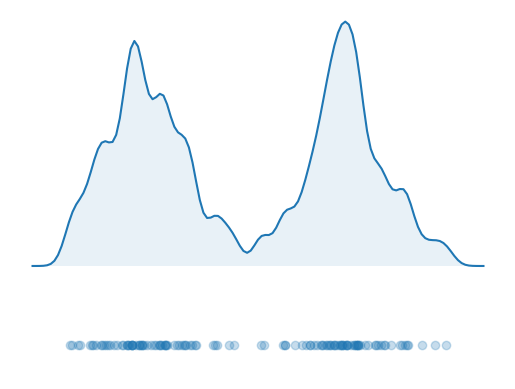

In [4]:
fig = plot_kde(test_data, bw=0.08)

Nice! The one-dimensional data at the bottom of the plot seems to contain two prominent modes, and the KDE shows two large peaks corresponding to these modes. So our data probably has two clusters. To cluster our data, we just need to find the peaks in the KDE and assign points to clusters if they lie "under" a given peak.

Let's go ahead and plot the peaks in our KDE along with their corresponding clusters.

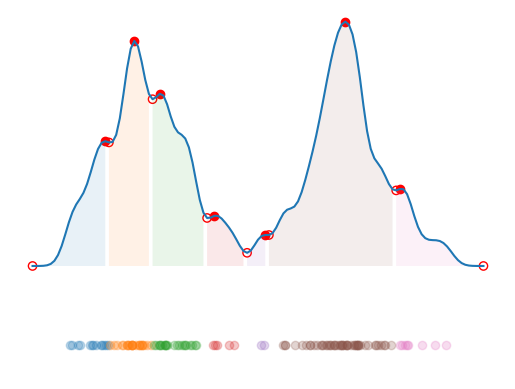

In [5]:
fig = plot_kde(test_data, bw=0.08, show_peaks=True, show_clusters=True)

Okay, so it's not *that* simple. Our KDE has many more than just two peaks, and so our data is broken into many more clusters than we would expect using this naive procedure.

It looks like many of our peaks are quite small. That is, they don't "stick out" much from the KDE. These peaks occur due to noise in either our dataset or our density estimate. From here on, we'll call these small peaks **noisy modes**, and we'll call the larger peaks **stable modes**.

### Solving the Problem

This isn't a huge deal, right? We'll just get rid of the noisy modes.

This is the right thing to do, but we'll need to go about it carefully. If we want every point in our dataset to be assigned to some cluster, we can't just filter out the noisy-mode clusters and keep only the stable-mode clusters. Instead, we'll want to **merge** the noisy modes into the larger, stable modes that they're a part of.

How will we decide that a noisy mode is "a part of" one mode and not another? We will simply take whichever of its neighboring mode increases the KDE the most. In other words, we'll merge peaks in the steepest "uphill" direction, following the KDE.

With good criteria for defining stable clusters in hand, we can now outline our merging procedure:
1. Sort peaks in order of prominence, from smallest to largest.
2. In sorted order, merge each peak into its most stable neighboring peak, following ascending gradients in the KDE.

Pretty simple! In the following sections, we'll visualize what this merging procedure looks like in action, and how it leads to a very natural clustering of our data.

### Cluster Merge Plotting Functions

Of course, we'll need another huge block of visualization functions first. Feel free to scroll on!

In [6]:
def get_peak_prominences_interactive(kde_x, kde_y):
    peak_idxs, _ = signal.find_peaks(kde_y)
    prominences, _, _ = signal.peak_prominences(kde_y, peak_idxs)

    sort_order = np.argsort(prominences)
    return peak_idxs[sort_order], prominences[sort_order]


def apply_prominence_threshold_interactive(peak_idxs, prominences, threshold, kde_x, kde_y):
    valley_idxs, _ = signal.find_peaks(-kde_y)
    valley_set = set(valley_idxs)

    sort_order = np.argsort(prominences)
    sorted_peaks = peak_idxs[sort_order]
    sorted_proms = prominences[sort_order]

    kept_peaks = list(peak_idxs.copy())

    sentinel_left = 0
    sentinel_right = kde_y.shape[0] - 1

    merges = []

    for peak, prom in zip(sorted_peaks, sorted_proms):
        if prom >= threshold:
            break

        active_valleys = np.array(sorted(valley_set))

        left_candidates = active_valleys[active_valleys < peak]
        right_candidates = active_valleys[active_valleys > peak]

        left_valley = left_candidates[-1] if len(left_candidates) else sentinel_left
        right_valley = right_candidates[0] if len(right_candidates) else sentinel_right

        sorted_by_pos = np.sort(peak_idxs)

        if kde_y[left_valley] >= kde_y[right_valley]:
            valley_set.discard(left_valley)
            left_peaks = sorted_by_pos[sorted_by_pos < peak]
            left_kept = [p for p in left_peaks if p in kept_peaks]
            merge_target = left_kept[-1] if left_kept else None
        else:
            valley_set.discard(right_valley)
            right_peaks = sorted_by_pos[sorted_by_pos > peak]
            right_kept = [p for p in right_peaks if p in kept_peaks]
            merge_target = right_kept[0] if right_kept else None

        kept_peaks.remove(peak)
        merges.append((peak, merge_target))

    boundary_idxs = np.array(sorted([sentinel_left, *valley_set, sentinel_right]))
    return boundary_idxs, merges


def _plot_prominences_interactive(prominences, threshold, ax):
    ax.cla()
    for i, p in enumerate(prominences):
        color = f"C{1}" if p >= threshold else f"C{0}"
        ax.bar(i, p, color=color)
    ax.axhline(threshold, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Peak (sorted by prominence)")
    ax.set_ylabel("Prominence")
    ax.set_title("Peak Prominences")
    ax.set_xticks(range(len(prominences)))
    return


def _plot_kde_clusters_interactive(clusters, boundary_idxs, kde_x, kde_y, data_ax, kde_ax):
    kde_ax.scatter(kde_x[boundary_idxs], kde_y[boundary_idxs],
                   facecolors="none", edgecolors="red")

    for i in range(len(boundary_idxs) - 1):
        kde_xc = kde_x[boundary_idxs[i]:boundary_idxs[i + 1]]
        kde_yc = kde_y[boundary_idxs[i]:boundary_idxs[i + 1]]
        kde_ax.fill_between(kde_xc, kde_yc, alpha=0.1)

    for c in clusters:
        data_ax.scatter(c, np.zeros_like(c), alpha=0.25)
    
    return


def _plot_kde_peaks_interactive(kde_x, kde_y, peak_idxs, ax):
    ax.scatter(kde_x[peak_idxs], kde_y[peak_idxs], color="red")
    return


def cluster_by_kde_modes_interactive(data, kde_x, kde_y, boundary_idxs):
    data = np.asarray(data)
    boundaries = kde_x[boundary_idxs]
    split_points = np.sort(boundaries)
    clusters = [
        data[(data >= split_points[i]) & (data < split_points[i + 1])]
        for i in range(len(split_points) - 1)
    ]
    return [c for c in clusters if len(c) > 0]


def _draw_kde_frame_interactive(x, kde_x, kde_y, peak_idxs, prominences, threshold, kde_ax, data_ax, prom_ax, merge=None):
    boundary_idxs, merges = apply_prominence_threshold_interactive(peak_idxs, prominences, threshold, kde_x, kde_y)
    clusters = cluster_by_kde_modes_interactive(x, kde_x, kde_y, boundary_idxs)

    kde_ax.plot(kde_x, kde_y, color="black", linewidth=1)
    kde_ax.set_axis_off()
    _plot_kde_clusters_interactive(clusters, boundary_idxs, kde_x, kde_y, data_ax, kde_ax)
    _plot_kde_peaks_interactive(kde_x, kde_y, peak_idxs[prominences >= threshold], kde_ax)

    if merge is not None:
        from_idx, to_idx = merge
        if to_idx is not None:
            fx, fy = kde_x[from_idx], kde_y[from_idx]
            tx, ty = kde_x[to_idx], kde_y[to_idx]
            offset = kde_y.max() * 0.02
            kde_ax.annotate(
                "", 
                xy=(tx, ty + offset), 
                xytext=(fx, fy + offset),
                arrowprops=dict(
                    arrowstyle="->, head_width=0.3, head_length=0.3",
                    color="black", 
                    lw=2.5,
                    shrinkA=10,
                    shrinkB=10,
                )
            )

    data_ax.set_axis_off()
    _plot_prominences_interactive(prominences, threshold, prom_ax)

    return


def plot_kde_interactive(x, bw=None):
    kde = stats.gaussian_kde(x, bw_method=bw)

    x_range = x.max() - x.min()
    kde_x = np.linspace(x.min() - 0.1 * x_range, x.max() + 0.1 * x_range, x.shape[0])
    kde_y = kde(kde_x)

    peak_idxs, prominences = get_peak_prominences_interactive(kde_x, kde_y)
    n_peaks = len(peak_idxs)

    thresholds = [prominences[0] - 1e-10] + [
        (prominences[i] + prominences[i + 1]) / 2
        for i in range(n_peaks - 1)
    ]

    n_steps = len(thresholds)
    fig = plt.figure(figsize=(6 * n_steps, 8))
    gs = fig.add_gridspec(3, n_steps, height_ratios=[0.45, 0.15, 0.4], hspace=0.3)

    plt.ioff()

    merges_per_step = [None]
    for i in range(1, len(thresholds)):
        _, prev_merges = apply_prominence_threshold_interactive(peak_idxs, prominences, thresholds[i-1], kde_x, kde_y)
        _, curr_merges = apply_prominence_threshold_interactive(peak_idxs, prominences, thresholds[i], kde_x, kde_y)
        new_merges = curr_merges[len(prev_merges):]
        merges_per_step.append(new_merges[0] if new_merges else None)

    for col, threshold in enumerate(thresholds):
        kde_ax  = fig.add_subplot(gs[0, col])
        data_ax = fig.add_subplot(gs[1, col], sharex=kde_ax)
        prom_ax = fig.add_subplot(gs[2, col])
        n_clusters = n_peaks - col
        kde_ax.set_title(f"k={n_clusters}", fontsize=10)
        _draw_kde_frame_interactive(x, kde_x, kde_y, peak_idxs, prominences, threshold,
                        kde_ax, data_ax, prom_ax, merge=merges_per_step[col])

    plt.suptitle("KDE Clustering by Peak Prominence", y=1.02)
    plt.tight_layout()
    plt.ion()
    plt.show()

    return

### Mode Seeking: Cluster Merging to Find Stable Modes

The merging procedure we defined is an example of "mode seeking". We start with many "modes" in our density estimate, the overwhelming majority of which are just the result of noise in our data or noise in our KDE. So we try to systematically find (or "seek") the **true modes** of the  density function.

In our case, we defined a procedure for doing this that involves merging smaller modes into larger ones in the direction of steepest ascent in the KDE. Let's finally take a look at how this works in practice. Starting with our example clustering from above, we'll merge noisy clusters into more stable clusters, and show each how each merge affects the clustering. We'll also show the prominences of the peaks that survive each merge, and use arrows to point in the direction of steepest ascent along which each merge is performed.

/tmp/ipykernel_1401/1083413149.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


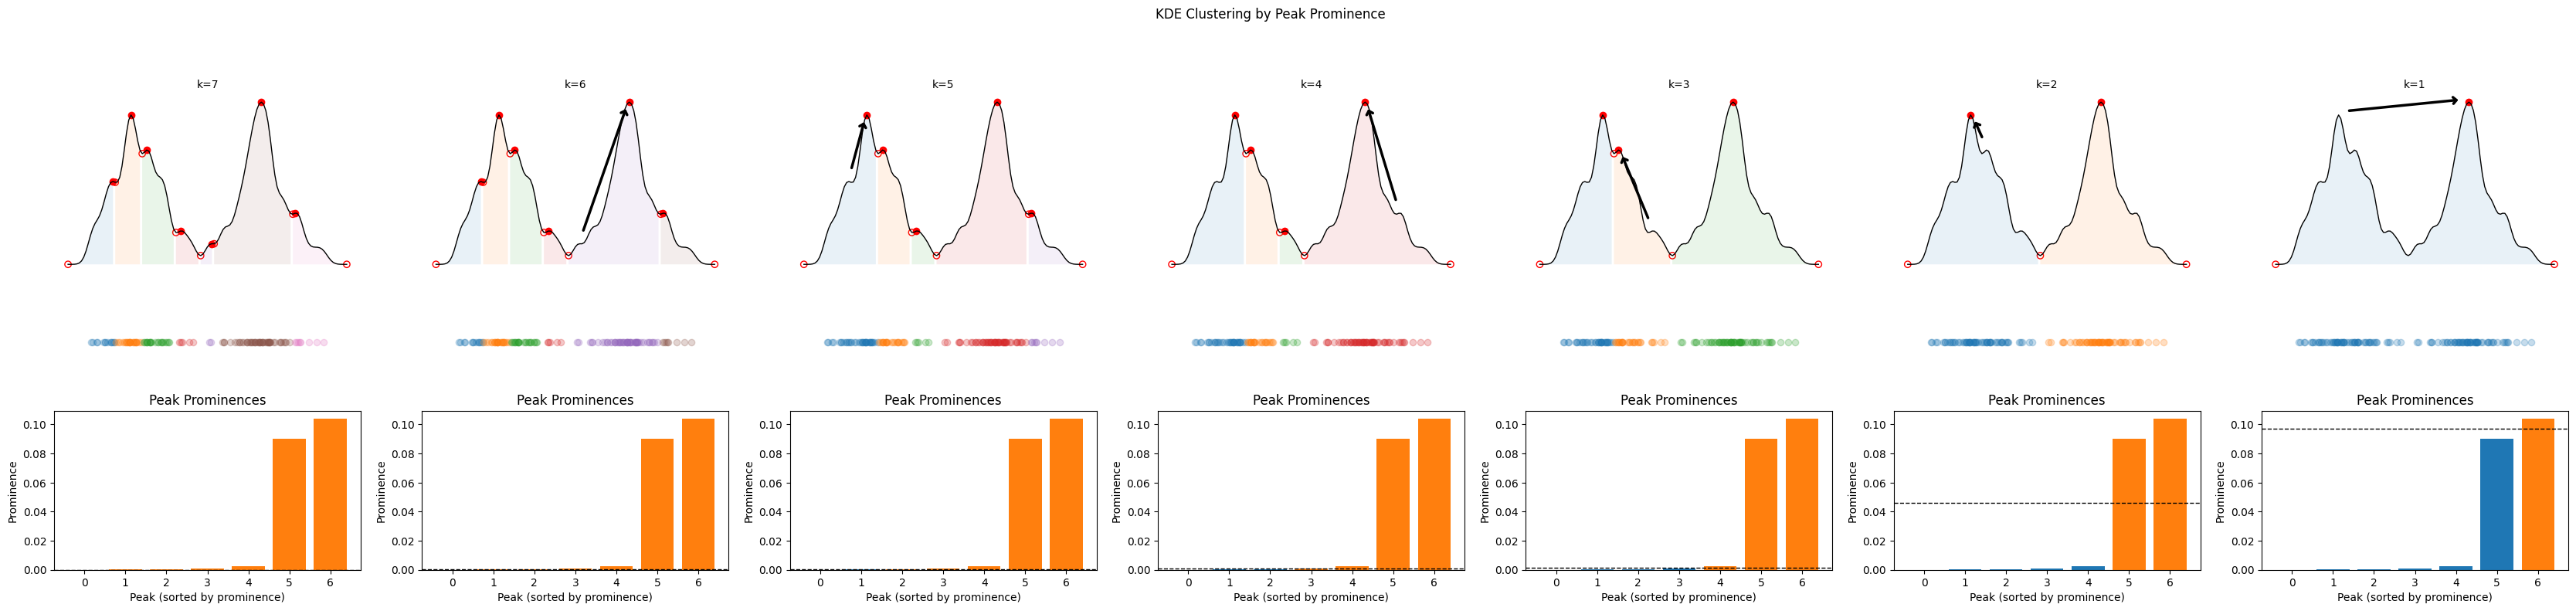

In [7]:
plot_kde_interactive(test_data, bw=0.08)

This procedure looks really good! The prominences of the noisy modes are so small that they barely register on the plot. Two large modes stand out, though, and these correspond precisely to the two most visually obvious clusters in our data. We can see the expected clustering at the second-to-last step, before everything gets merged into a single mode.

Given that the expected clustering corresponds to such a significant and sudden jump in the prominences, it is reasonable to assume that we could use this jump as an indication of where we should stop our merging procedure. This is generally true, and it is how ToMATo determines the number of clusters to return by default.

### One Last Example

To demonstrate how powerful this merging procedure is, let's take a look at one more dataset.

In [8]:
X, _ = make_blobs(125, n_features=1, centers=[[0], [3], [8], [12]], cluster_std=1.0, random_state=42)
test_data = X[:,0]

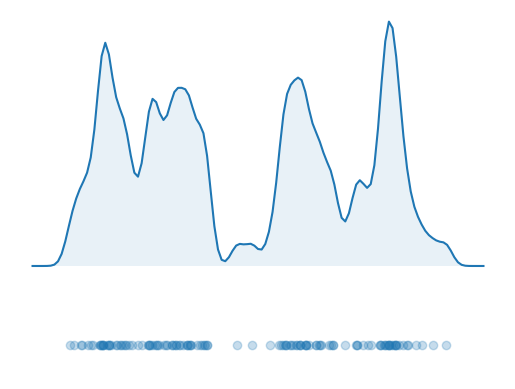

In [9]:
fig = plot_kde(test_data, bw=0.06)

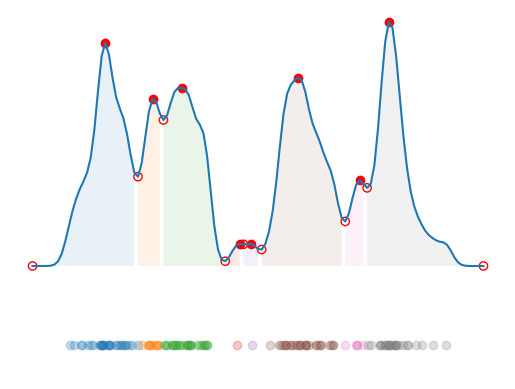

In [10]:
fig = plot_kde(test_data, bw=0.06, show_peaks=True, show_clusters=True)

In this dataset, it's not as clear what the "correct" number of clusters is. It seems like there are two major groupings of data. But the right half of the dataset seems like it might actually consist two clusters. And the left half, while it's not so clear, seems like it might also have two dense modes hiding in it.

How will our mode-seeking algorithm sort this out?

/tmp/ipykernel_1401/1083413149.py:172: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


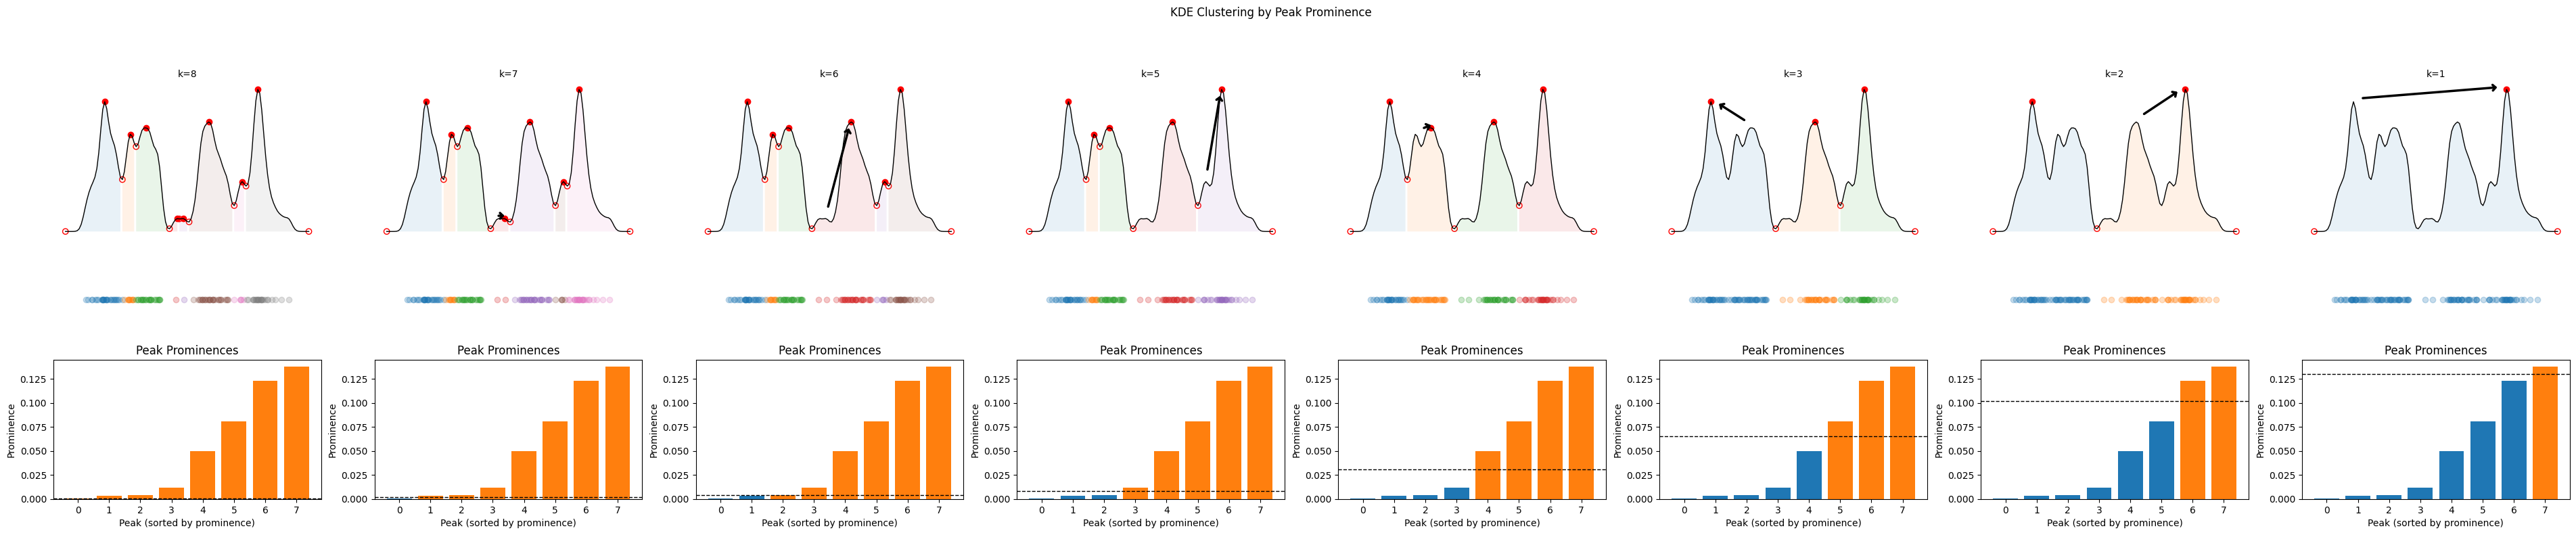

In [11]:
plot_kde_interactive(test_data, bw=0.06)

It looks like our mode-seeking procedure is able to effectively find the clustering that we would expect to see regardless of whether we thought there were 2, 3, or 4 clusters in the data. In this case, there is no obvious "jump" in the cluster prominences. Instead, it appears that the data supports several possible clusterings. In such a scenario, one may be more interested in how strongly the data supports clusterings at different thresholds, rather than choosing a single, flat clustering.

Our chosen approach to clustering will help us out here. It seems that a cluster's prominence is directly related to its "significance". We may want to use this measurement to perform some statistical analysis or to understand the cluster structure of our data. Moreover, our clustering procedure allows us to pull back a number of candidate clusterings if we're interested in doing so. This gives us a great amount of flexibility in approaching cluster analysis.

## III. Conclusion

This approach to clustering via mode-seeking appears to give us a very simple set of rules for extracting stable clusters from noisy density estimates. This works well for one-dimensional data. But what do we do when our data lives in two, three, four, or hundreds of dimensions? In these higher-dimensional settings, our clusters might be very irregularly shaped or have very different densities from one cluster to the next.

Defining a general (and fast!) procedure for extracting stable, density-based clusters in such a flexible way is precisely what ToMATo and ToMAToSCAN aim to do. If you're interested, go ahead and check out the "How ToMAToSCAN Works" notebook to read more.